# Hviddal ca. 1184 Ma paleomagnetic pole

## Geologic Context

The Gardar Igneous Province is a major magmatic event in Laurentia exposed in Greenland; it  is composed of a suite of peralkaline igneous complexes and basic dike swarms.  In the eastern part of the province, there are NE-SW trending dikes and alkaline plutons that are interpeted to be a renewed and final stage of magmatism.  The earliest NE-SW trending intrusions exposed are a number of giant dikes exposed on the island of Tugtutôq. The earliest of these is the 0.4-0.7 km wide Hviddal syenite dike running for 22 km along the axis of the island. There are some compositional changes of saturation from east to west, most notably the syenite merges into syeno-gabbro about 0.1 km wide on its margins.  

The Hviddal dike is cut by a system of giant gabbro dikes; they generally trend NE-SW with just a slight change in direction to be more ENE-SSW.

^^paraphrased from Piper et al. (1977)

## Paleomagnetic And Rock Magnetic Data
Piper (1977) drilled cores at 8 sites within the giant Hviddal syenite dike; three samples were within the marginal syeno-gabbro facies (ultrabasic) and one other was noted as an ultramafic instrusion. Samples were demagnetized in steps of 5 or 10  mT up to peak fields between 40 and 100 mT; demagnetization was halted when increased in magnetization (a.k.a. a GRM) occurred. Components were determined using  Fisher mean over the stable range (typically 15-50 mT).

Syenite samples had exponential falls in moment interpreted to indicate titanomagnetite as the predominant character. Thermomagnetic curves were performed on at least one sample from each site confirming this titanomagnetite carrier with Curie temperatures ranging from 480 - 540°C.

One site were excluded from the mean direction of the syenite dike; this was determined based on grouping with other directions in the study that had much shallower easterly directions compared to the other samples.  This direction is similar to a NE trending swarm of basic and intermediate minor dikes in the same region so was suggested to be an overprint, etc.

No structural corrections were performed on these samples/sites.

## Age Constraints

- Current bracket: nominal age 1184 Ma, lomagage 1179.0 Ma, himagage 1189.0 Ma.
- Compilation method note: 1184±5 Ma. On the island of Tuttutooq, the Hviddal Giant Dyke complex (name by earlier studies such as Piper, 1977) is called the Older Giant Dyke Complex by other authors, especially those that conduct more recent studies. Blaxland 1978 conducted Rb-Sr radiometric dating on the dike that obtained a date of 1175±9 Ma, but an unpublished baddeleyite Pb-Pb date from Heaman was summarized in Upton, 2013 (https://doi.org/10.34194%2Fgeusb.v29.4692). We use the baddeleyite here. 

## References

- Paleomagnetic source: Piper, J.D.A. (1977). Palaeomagnetism of the giant dykes of Tugtutoq and Narssaq Gabbro, Gardar Igneous Province, South Greenland. BGS Denmark, 26, 85-94.  DOI: 10.37570/bgsd-1976-26-06 
- Geochronology / age-constraint note (compilation): Upton, B. G. J. (2013). Tectono-magmatic evolution of the younger Gardar southern rift, South Greenland. Geological Survey of Denmark and Greenland Bulletin, 29, 1–124. https://doi.org/10.34194/geusb.v29.4692

## Calculations

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import pmagpy.pmag as pmag
import pmagpy.ipmag as ipmag
import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib_inline

import pole_tools as pt

## Read in sites

In [3]:
sites_df = pd.read_csv('../data/1184_Hviddal/sites.txt', sep='\t',header=1)

In [4]:
sites_df.head()

,age,age_high,age_low,age_sigma,age_unit,citations,description,dir_alpha95,dir_dec,dir_inc,dir_k,dir_n_samples,dir_tilt_correction,geologic_classes,geologic_types,lat,lithologies,location,lon,method_codes,result_quality,result_type,site,vgp_dm,vgp_dp,vgp_lat,vgp_lon
0,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,12.3,295.8,25.5,30,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,1,NaN,NaN,24,207
1,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,10.3,281.9,39.7,44,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,2,NaN,NaN,25,225
2,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,9.9,293.0,36.5,47,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,3,NaN,NaN,29,214
3,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,10.1,301.4,60.6,59,5,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,4,NaN,NaN,50,223
4,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,10.8,286.0,44.0,73,4,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,5,NaN,NaN,30,223


## Site location map

Note that there is no latitude and longitude information provided for these samples.  There is a hand-drawn map and it needs to be georeferenced.  In the meantime, place holder latitude and longitude was used near the center of the samples sites based on visual examination.

In [5]:
study_lat =  60.88
study_lon =  -46.34

In [6]:
pt.plot_site_map(sites_df)

# Add VGPs

Piper (1977) reported VGP poles for each site but we wanted to check the calculations to see if a rotation was applied.

In [7]:
sites_df['vgp_lon'], sites_df['vgp_lat'], sites_df['vgp_dp'], sites_df['vgp_dm'] = pmag.dia_vgp(sites_df['dir_dec'], sites_df['dir_inc'], sites_df['dir_alpha95'], sites_df['lat'], sites_df['lon'])

In [8]:
sites_df.head()

,age,age_high,age_low,age_sigma,age_unit,citations,description,dir_alpha95,dir_dec,dir_inc,dir_k,dir_n_samples,dir_tilt_correction,geologic_classes,geologic_types,lat,lithologies,location,lon,method_codes,result_quality,result_type,site,vgp_dm,vgp_dp,vgp_lat,vgp_lon
0,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,12.3,295.8,25.5,30,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,1,13.255764,7.142897,24.122130,207.307864
1,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,10.3,281.9,39.7,44,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,2,12.364120,7.420944,25.315886,224.940240
2,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,9.9,293.0,36.5,47,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,3,11.550428,6.738000,28.781136,213.721202
3,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,10.1,301.4,60.6,59,5,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,4,15.389122,11.724013,50.306861,222.094229
4,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,10.8,286.0,44.0,73,4,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,5,13.520218,8.462792,30.042690,223.312753


These match those input by Piper (1977) within rounding errors so we will stick with their calculations until we have a precise georeferenced map with site latitude-longitudes.

In [9]:
sites_df = pd.read_csv('../data/1184_Hviddal/sites.txt', sep='\t',header=1)

## Site directions (as measured at site)

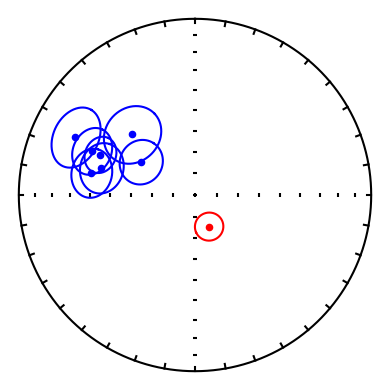

In [10]:
plt.figure(figsize = (4,4))
ipmag.plot_net()

for row, site in sites_df.iterrows():
    if  site['result_quality'] == 'g':
        col = 'b'
    elif site['result_quality'] == 'b':
        col = 'r'
    ipmag.plot_di_mean(dec=site['dir_dec'],
                       inc=site['dir_inc'],
                       a95=site['dir_alpha95'],
                       color=col)

Dec: 294.3  Inc: 42.7
Number of directions in mean (n): 7
Angular radius of 95% confidence (a_95): 9.9
Precision parameter (k) estimate: 38.2


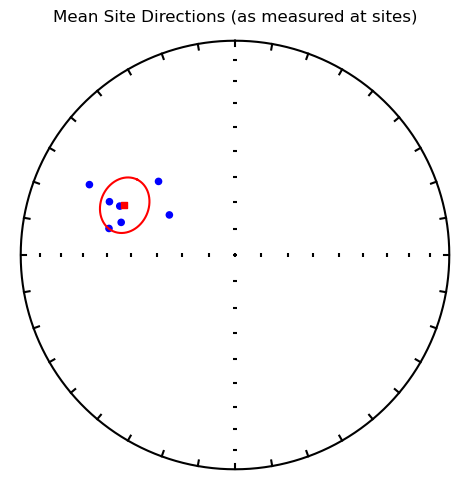

In [11]:
sites_subset = sites_df[sites_df['result_quality'] == 'g']

dir_block, dir_mean = pt.compute_mean_direction(sites_subset)
ipmag.print_direction_mean(dir_mean)

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], 
                   color='red', marker='s')
ipmag.plt.title('Mean Site Directions (as measured at sites)')
ipmag.plt.show()

In [12]:
sites_subset

,age,age_high,age_low,age_sigma,age_unit,citations,description,dir_alpha95,dir_dec,dir_inc,dir_k,dir_n_samples,dir_tilt_correction,geologic_classes,geologic_types,lat,lithologies,location,lon,method_codes,result_quality,result_type,site,vgp_dm,vgp_dp,vgp_lat,vgp_lon
0,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,12.3,295.8,25.5,30,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,1,NaN,NaN,24,207
1,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,10.3,281.9,39.7,44,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,2,NaN,NaN,25,225
2,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,9.9,293.0,36.5,47,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,3,NaN,NaN,29,214
3,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,10.1,301.4,60.6,59,5,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,4,NaN,NaN,50,223
4,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,10.8,286.0,44.0,73,4,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,5,NaN,NaN,30,223
5,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,13.2,313.9,49.0,27,6,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,6,NaN,NaN,47,200
7,1184,1189,1179,5,Ma,10.37570/bgsd-1976-26-06,NaN,7.8,293.0,41.2,98,5,0,Igneous,Intrusion,60.88,Syenite,Hviddal,-46.34,DE-FM,g,i,8,NaN,NaN,32,216


## Mean pole from VGPs

Plon: 215.6  Plat: 34.1
Number of directions in mean (n): 7
Angular radius of 95% confidence (A_95): 9.6
Precision parameter (k) estimate: 40.3


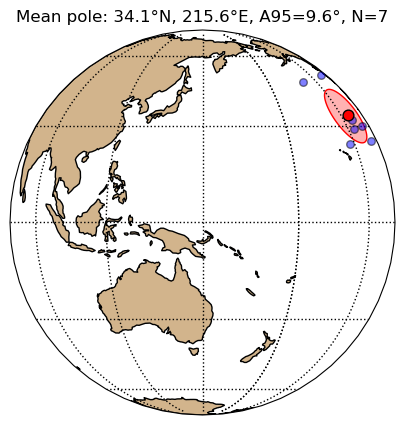

In [13]:
vgp_block, pole_mean = pt.compute_mean_pole(sites_subset)
ipmag.print_pole_mean(pole_mean)
pole_plot = pt.plot_vgps_and_pole(vgp_block, pole_mean, figsize=(5,5))

## Euler rotation into the Laurentia reference frame

The Greenland-to-Laurentia rotation of Roest and Srivastava (1989) (Swanson-Hysell, 2021, Table 4.1) is applied with `pmag.pt_rot`: Euler pole 67.5 deg N / -118.5 deg E, angle -13.8 deg. This reproduces the rotated pole position carried in the project pole database.

In [14]:
euler_greenland = [67.5, -118.5, -13.8]   # [lat, lon, angle]; Roest and Srivastava (1989)
rlat, rlon = pmag.pt_rot(euler_greenland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:       {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Greenland frame): 34.1 N / 215.6 E
rotated into the Laurentia frame:       36.8 N / 206.1 E


## Pole in the context of the Laurentia APWP

The pole is shown in **separate** plots in its unrotated position (present-day Greenland coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path).

Text(0.5, 1.0, 'Unrotated — present-day Greenland frame')

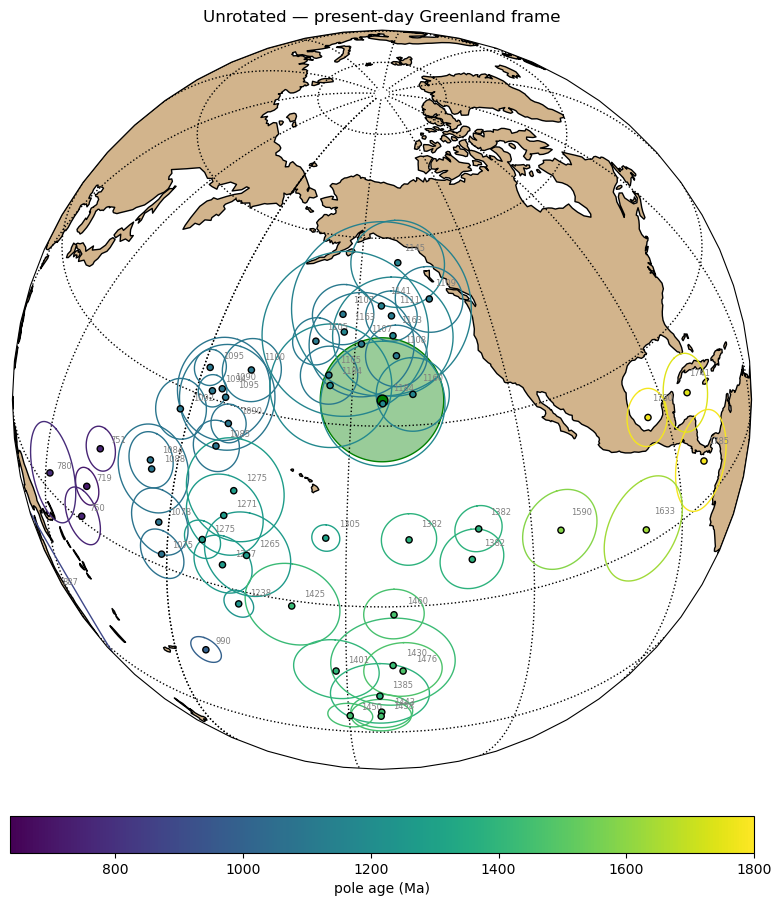

In [15]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'], pole_mean['alpha95'], age_min=635, age_max=1800, projection='orthographic', central_longitude=pole_mean['dec'], central_latitude=pole_mean['inc'])
plt.title('Unrotated — present-day Greenland frame')

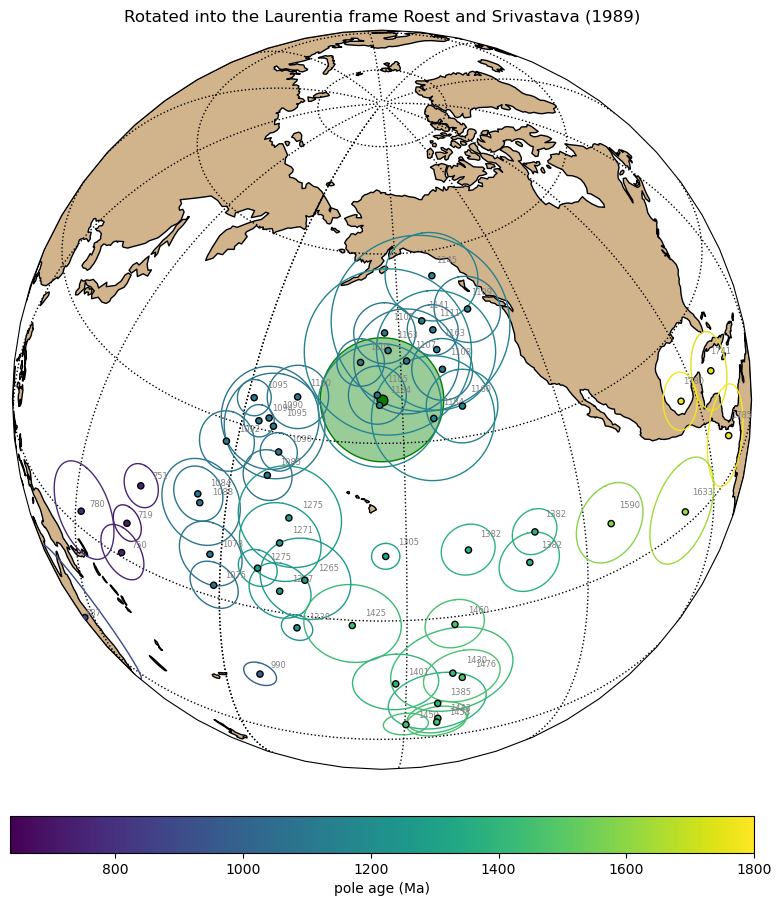

In [16]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],pole_rotated['alpha95'], 
                          age_min=635, age_max=1800,projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame Roest and Srivastava (1989)')
plt.show()

## R2: Deenen test

A_95 of 9.6 passes Deenen et al. (2011) criteria of being between 5.5 and 24.1 for this number of sites


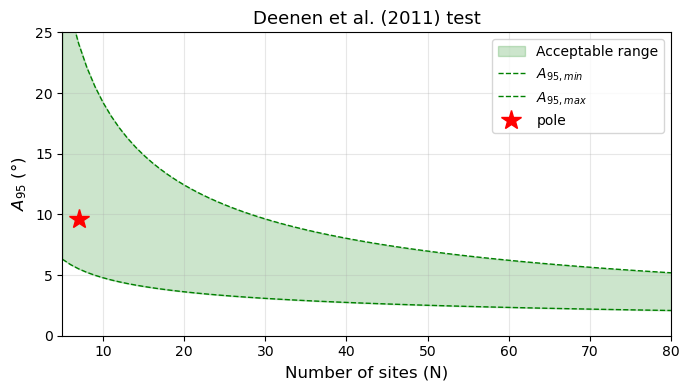

In [17]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()

## R7: Comparison with younger Laurentia poles

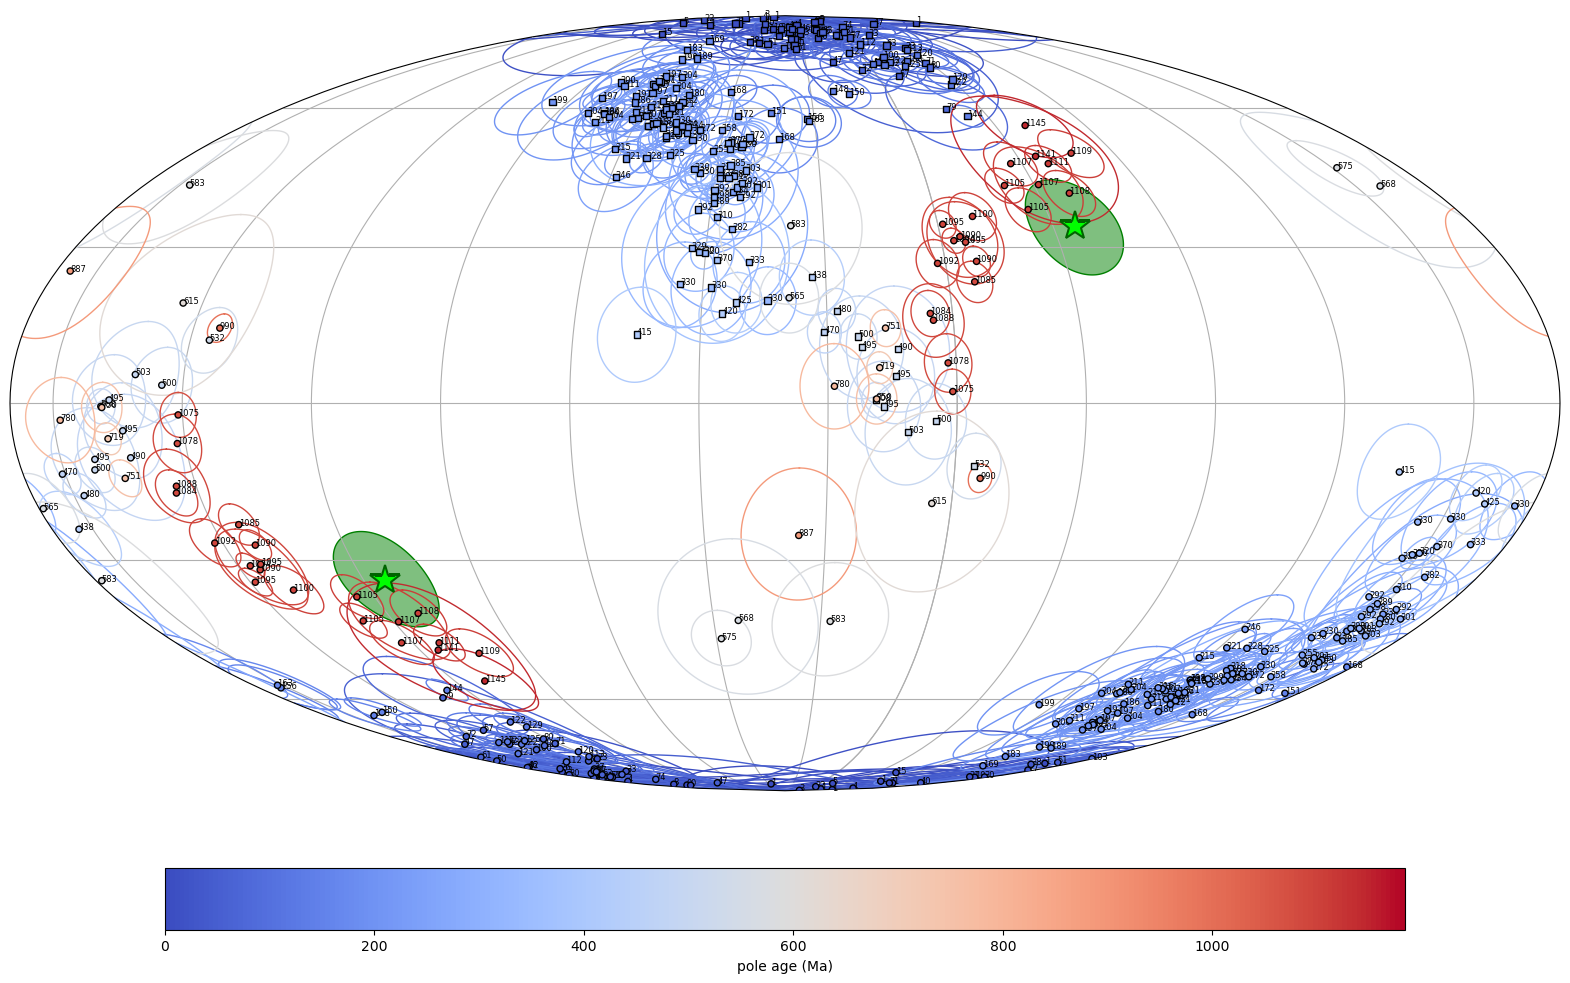

Text(0.5, 1.0, 'Rotated into the Laurentia frame Roest and Srivastava (1989)')

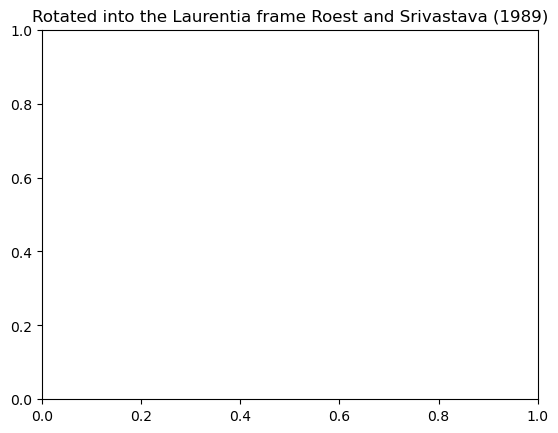

In [18]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Hviddal', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                  pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                  pole_A95=pole_mean['alpha95'], pole_age=1184)
plt.title('Rotated into the Laurentia frame Roest and Srivastava (1989)')

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | Unpublished Pb-Pb baddeleyite age of 1184±5 Ma from Heaman was summarized in Upton, 2013|
| 2 | Techniques and statistical analysis | **0** | (a) Only AF demagnetization (b) Fisher means used not PCA. (c) N = 38 samples, k = 40.3, A95 = 9.6° passes Deenen et al. (2011) envelope (5.5-24.1°). B = 7 sites ≦ 8 so fail there. |
| 3 | Magnetic mineralogy characterized | **1** | Thermomagnetic curves for titanomagnetite carrier. |
| 4 | Field tests constrain age of magnetization | **0** | No fold, baked contact, or conglomerate test were performed. |
| 5 | Structural control / tectonic coherence | **0** | No tilt-correction was applied|
| 6 | Presence of reversals | **0** | Does not contain reversals|
| 7 | No resemblance to younger poles | **1** | No overlap with younger poles. |
| | **Total R-score** | **3/7** | |

## Nordic workshop ranking

Prior Nordic Workshop compilations of paleomagnetic poles with expert-assigned rankings (Evans et al., 2021) have given the pole from the Hviddal Dike a 'B' ranking. 

Our assessment and community evaluation by the 2026 Nordic Workshop is that careful evaluation of the pole suggests it should remain at a 'B' ranking, due to the lack of PCA, tilt-correction and field tests (which are described as possible).  

In [19]:
Hviddal_summary = pt.make_nordic_summary(terrane='Laurentia', 
                                        rockname='Hviddal', 
                                        sites=sites_subset,
                                        dir_mean=dir_mean,
                                        pole_mean=pole_mean,
                                        study_lon=study_lon,
                                        study_lat=study_lat,
                                        component_comment='',
                                        tests='',
                                        R1=1,
                                        R2=0,
                                        R3=1,
                                        R4='',
                                        R5=0,
                                        R6=0,
                                        R7=1,
                                        Grade='B',
                                        nominal_age=1184,
                                        lomagage=1179,
                                        himagage=1189,
                                        REF_method='Unpublished Pb-Pb baddeleyite age of 1184±5 Ma from Heaman was summarized in Upton, 2013, DOI: 10.34194/geusb.v29.4692',
                                        POLE_AUTHORS='Piper, J.D.A.',
                                        YEAR=1977,
                                        JOURNAL='BGS Denmark',
                                        VOLUME=26,
                                        VPAGES='85-94',
                                        TITLE='Palaeomagnetism of the giant dykes of Tugtutoq and Narssaq Gabbro, Gardar Igneous Province, South Greenland',
                                        COMMENT='Recalculated pole using site VGPs provided in Piper (1977)'
                                        )
Hviddal_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,DEC,INC,abs(I),KD,ED95,PLAT,PLONG,DP,DM,A95,f,INCf,PLATf,PLONf,DPf,DMf,A95f,f,INCf,PLATf,PLONf,DPf,DMf,A95f,%REV,DEMAGCODE,40,24,10,16,Q2,Q3,Q4,Q5,Q6,Q7,Q(7),R1,R2,R3,R4,R5,R6,R7,R,Grade,nominal age,lomagage,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Hviddal,,,,0,60.88,-46.34,7,38,294.3,42.7,42.7,38.2,9.9,34.1,215.6,,,9.6,1.0,42.7,34.1,215.6,,,9.6,1.0,42.7,34.1,215.6,,,9.6,,,,,,,,,,,,,,1,0,1,,0,0,1,3,B,1184,1179,1189,Unpublished Pb-Pb baddeleyite age of 1184±5 Ma...,Hviddal,"Piper, J.D.A.",1977,BGS Denmark,26,85-94,Palaeomagnetism of the giant dykes of Tugtutoq...,Recalculated pole using site VGPs provided in ...


In [20]:
# save the summary dictionary as a single-row CSV in data/nordic_summaries
pt.save_nordic_summary(Hviddal_summary, '1184_Hviddal')

'../data/nordic_summaries/1184_Hviddal.csv'